In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [174]:
ticker_1 = input("Inserisci il ticker del primo titolo: ")
ticker_2 = input("Inserisci il ticker del secondo titolo: ")

Inserisci il ticker del primo titolo:  SPY
Inserisci il ticker del secondo titolo:  IVV


In [175]:
end_date = datetime.now()
start_date = end_date - timedelta(days=365*5)

In [176]:
data1 = yf.download(ticker_1,start=start_date,end=end_date,interval='1mo')
data2 = yf.download(ticker_2,start=start_date,end=end_date,interval='1mo')

print(data1.head())
print(data2.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open      Volume
Ticker             SPY         SPY         SPY         SPY         SPY
Date                                                                  
2020-09-01  311.822144  334.038607  297.771547  326.086851  1814712700
2020-10-01  305.264374  330.953903  301.581081  315.687893  1629016100
2020-11-01  338.470123  340.638971  305.918800  308.685963  1535244300
2020-12-01  349.520050  353.801630  338.442125  341.751486  1344541500
2021-01-01  347.432922  362.247663  342.504063  352.352384  1402265400
Price            Close        High         Low        Open    Volume
Ticker             IVV         IVV         IVV         IVV       IVV
Date                                                                
2020-09-01  312.176361  334.656489  298.112369  326.686250  86013100
2020-10-01  305.718872  331.501834  302.079590  316.179485  79587900
2020-11-01  339.032318  341.243881  306.428030  309.227483  81678500
2020-12-01  350.29

In [177]:
returns_df = pd.DataFrame()
returns_df[ticker_1] = data1['Close'].pct_change()
returns_df[ticker_2] = data2['Close'].pct_change()
returns_df = returns_df.dropna()

print(returns_df.head())

                 SPY       IVV
Date                          
2020-10-01 -0.021030 -0.020685
2020-11-01  0.108777  0.108968
2020-12-01  0.032647  0.033221
2021-01-01 -0.005971 -0.005956
2021-02-01  0.027805  0.027589


In [178]:
statistics_df = pd.DataFrame({
    "Expected Returns": returns_df.mean(),
    "Variance": returns_df.var(),
    "Standard Deviation": returns_df.std()
})

print(statistics_df)

     Expected Returns  Variance  Standard Deviation
SPY          0.012824  0.002175            0.046638
IVV          0.012891  0.002182            0.046710


In [179]:
corr = returns_df[ticker_1].corr(returns_df[ticker_2])
corr = np.round(corr,6)

print(corr)

0.999913


In [180]:
weights = [round(x * 0.01, 2) for x in range(-100,201)]
print(weights)

[-1.0, -0.99, -0.98, -0.97, -0.96, -0.95, -0.94, -0.93, -0.92, -0.91, -0.9, -0.89, -0.88, -0.87, -0.86, -0.85, -0.84, -0.83, -0.82, -0.81, -0.8, -0.79, -0.78, -0.77, -0.76, -0.75, -0.74, -0.73, -0.72, -0.71, -0.7, -0.69, -0.68, -0.67, -0.66, -0.65, -0.64, -0.63, -0.62, -0.61, -0.6, -0.59, -0.58, -0.57, -0.56, -0.55, -0.54, -0.53, -0.52, -0.51, -0.5, -0.49, -0.48, -0.47, -0.46, -0.45, -0.44, -0.43, -0.42, -0.41, -0.4, -0.39, -0.38, -0.37, -0.36, -0.35, -0.34, -0.33, -0.32, -0.31, -0.3, -0.29, -0.28, -0.27, -0.26, -0.25, -0.24, -0.23, -0.22, -0.21, -0.2, -0.19, -0.18, -0.17, -0.16, -0.15, -0.14, -0.13, -0.12, -0.11, -0.1, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.5

In [181]:
p_exp_return = []
p_variance = []
p_stdev = []

t1_er = statistics_df.loc[ticker_1, 'Expected Returns']
t2_er = statistics_df.loc[ticker_2, 'Expected Returns']
t1_var = statistics_df.loc[ticker_1, 'Variance'] 
t2_var = statistics_df.loc[ticker_2, 'Variance']
t1_sd = statistics_df.loc[ticker_1, 'Standard Deviation']
t2_sd = statistics_df.loc[ticker_2, 'Standard Deviation']

for w in weights:
    
    p_er = t1_er * w + t2_er * (1 - w)
    p_exp_return.append(float(p_er))

    p_var = t1_var*(w**2) + t2_var*((1-w)**2) + 2*w*(1-w)*t1_sd*t2_sd*corr
    p_variance.append(p_var)

    p_sd = np.sqrt(p_var)
    p_stdev.append(p_sd)

In [182]:
portfolio_df = pd.DataFrame({
    "Weights": weights,
    "Portfolio ER": p_exp_return,
    "Portfolio Var": p_variance,
    "Portfolio SD": p_stdev,
})

print(portfolio_df)

     Weights  Portfolio ER  Portfolio Var  Portfolio SD
0      -1.00      0.012958       0.002189      0.046791
1      -0.99      0.012958       0.002189      0.046790
2      -0.98      0.012957       0.002189      0.046789
3      -0.97      0.012956       0.002189      0.046788
4      -0.96      0.012956       0.002189      0.046788
..       ...           ...            ...           ...
296     1.96      0.012760       0.002169      0.046576
297     1.97      0.012759       0.002169      0.046575
298     1.98      0.012759       0.002169      0.046575
299     1.99      0.012758       0.002169      0.046574
300     2.00      0.012757       0.002169      0.046573

[301 rows x 4 columns]


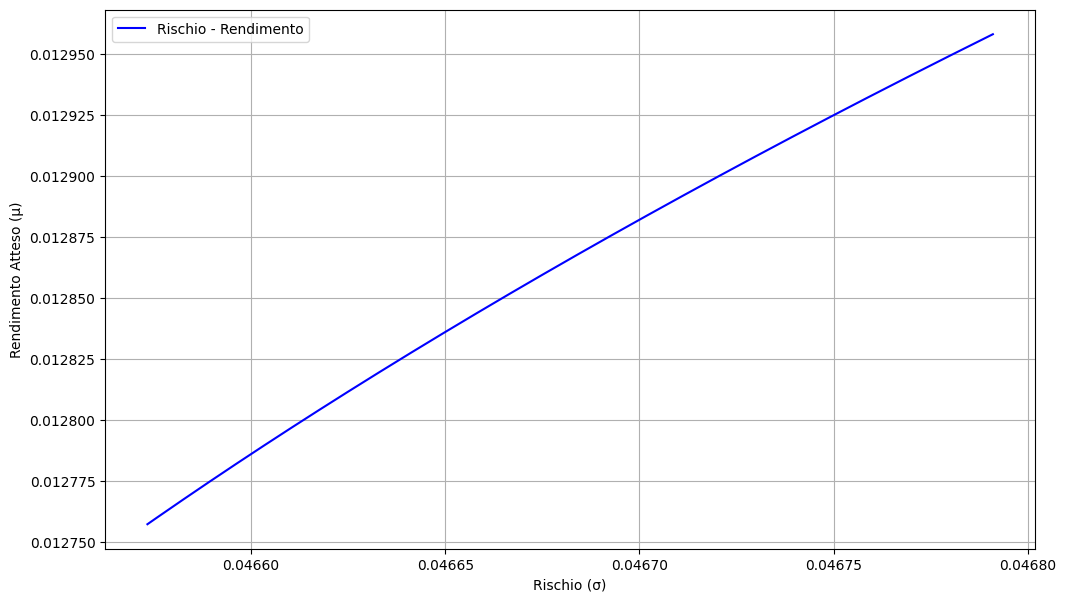

In [183]:
plt.figure(figsize=(12,7))
plt.plot(p_stdev, p_exp_return, color='blue', label='Rischio - Rendimento')

plt.xlabel('Rischio (σ)')
plt.ylabel('Rendimento Atteso (µ)')
plt.grid(True)

plt.legend()
plt.show()